# install

In [ ]:
# Cài đặt hoặc nâng cấp vnstock
!pip install -U vnstock pmdarima

In [ ]:
from vnstock import Quote
quote = Quote(symbol='ACB', source='KBS')

# Cell 1: Load dữ liệu

In [ ]:
# Cell 1: load dữ liệu
from vnstock import Quote
import pandas as pd
import numpy as np
import time
from scipy.stats import spearmanr, norm

SYMBOLS = [
    "ACB", "BID", "CTG", "HDB", "LPB",
    "MBB", "STB", "TCB",
    "VCB", "VIB",  "VPB",
]

START, END = "2024-01-01", "2025-12-31"
N_FWD = 5

raw = {}

for i, sym in enumerate(SYMBOLS, 1):

    # Nghỉ sau mỗi 18 request để tránh chạm limit 20/phút
    if i > 1 and (i - 1) % 18 == 0:
        print("⏳ Nghỉ 65 giây để tránh rate limit...")
        time.sleep(65)

    print(f"[{i}/{len(SYMBOLS)}] Loading {sym}...")

    try:
        df = Quote(symbol=sym, source="KBS").history(start=START,end=END,interval="d")

        raw[sym] = df.set_index("time")[["close", "open", "volume"]]

    except Exception as e:
        print(f"❌ {sym}: {type(e).__name__}")
        print(e)
        continue

price_df = pd.DataFrame({
    sym: d["close"] for sym, d in raw.items()
}).sort_index()

open_df = pd.DataFrame({
    sym: d["open"] for sym, d in raw.items()
}).sort_index()

volume_df = pd.DataFrame({
    sym: d["volume"] for sym, d in raw.items()
}).sort_index()

print(f"\n✅ Đã tải: {len(raw)}/{len(SYMBOLS)} mã")
print("Price shape:", price_df.shape)

price_df.head()

[1/11] Loading ACB...
[2/11] Loading BID...
[3/11] Loading CTG...
[4/11] Loading HDB...
[5/11] Loading LPB...
[6/11] Loading MBB...
[7/11] Loading STB...
[8/11] Loading TCB...
[9/11] Loading VCB...
[10/11] Loading VIB...
[11/11] Loading VPB...

✅ Đã tải: 11/11 mã
Price shape: (499, 11)


,ACB,BID,CTG,HDB,LPB,MBB,STB,TCB,VCB,VIB,VPB
time,,,,,,,,,,,
2024-01-02 07:00:00,14.80,32.53,18.38,12.29,12.09,9.63,27.75,14.85,55.04,12.80,17.12
2024-01-03 07:00:00,15.13,33.13,18.65,12.35,12.24,9.78,28.50,15.08,55.70,12.99,17.35
2024-01-04 07:00:00,15.32,33.02,19.33,12.60,12.42,10.26,28.60,15.31,56.63,13.18,17.58
2024-01-05 07:00:00,15.41,33.66,19.60,12.66,12.50,10.47,29.30,15.36,56.82,13.38,17.44
2024-01-08 07:00:00,15.34,35.10,19.97,12.69,12.46,10.57,29.20,15.78,57.22,13.51,17.48


# Cell 2: Tính log return

In [ ]:
# Cell 2: Log-return (dùng cho các phân tích khác nếu cần) + chuẩn bị data
log_return_df = np.log(price_df / price_df.shift(1)).dropna()

print("Số mã tải thành công:", price_df.shape[1])
print("Symbols:", list(price_df.columns))
print("Date range:", price_df.index.min(), "→", price_df.index.max())

Số mã tải thành công: 11
Symbols: ['ACB', 'BID', 'CTG', 'HDB', 'LPB', 'MBB', 'STB', 'TCB', 'VCB', 'VIB', 'VPB']
Date range: 2024-01-02 07:00:00 → 2025-12-31 07:00:00


# Cell 3: Dùng Engle Granger để kiểm tra đồng liên kết cho các cặp

In [ ]:
# Cell 3: Engle-Granger cointegration test cho TẤT CẢ các cặp
from statsmodels.tsa.stattools import coint
from itertools import combinations

results = []

for sym1, sym2 in combinations(price_df.columns, 2):
    # Lấy 2 series, drop NaN chung để đảm bảo cùng độ dài
    pair_df = price_df[[sym1, sym2]].dropna()

    if len(pair_df) < 30:  # quá ít data thì bỏ qua
        continue

    p1, p2 = pair_df[sym1], pair_df[sym2]

    # Engle-Granger test — trả về (t-stat, p-value, critical values)
    t_stat, p_value, crit_values = coint(p1, p2)

    results.append({
        "pair": f"{sym1}-{sym2}",
        "sym1": sym1,
        "sym2": sym2,
        "t_stat": t_stat,
        "p_value": p_value,
        "n_obs": len(pair_df)
    })

coint_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

print(f"Tổng số cặp đã test: {len(coint_df)}")
print("\nTop 10 cặp cointegrated mạnh nhất (p-value thấp nhất):")
print(coint_df.head(10).to_string(index=False))

Tổng số cặp đã test: 55

Top 10 cặp cointegrated mạnh nhất (p-value thấp nhất):
   pair sym1 sym2    t_stat  p_value  n_obs
CTG-STB  CTG  STB -4.168567 0.004069    499
MBB-STB  MBB  STB -3.710823 0.017747    499
ACB-VPB  ACB  VPB -3.407198 0.041557    499
VCB-VPB  VCB  VPB -3.345804 0.048737    499
VIB-VPB  VIB  VPB -3.343492 0.049026    499
CTG-MBB  CTG  MBB -3.215148 0.067431    499
ACB-STB  ACB  STB -3.044646 0.099971    499
ACB-TCB  ACB  TCB -2.984622 0.113906    499
ACB-LPB  ACB  LPB -2.907240 0.133933    499
STB-TCB  STB  TCB -2.888576 0.139121    499


2 cặp có p value thấp nhất là CTG và STB

# Cell 4: Chọn cặp tốt nhất, tính spread bằng OLS regression

In [ ]:
# Cell 4: Chọn cặp tốt nhất, tính spread bằng OLS regression
import statsmodels.api as sm

best_pair = coint_df.iloc[0]
sym1, sym2 = best_pair["sym1"], best_pair["sym2"]

print(f"🏆 Cặp tốt nhất: {sym1} - {sym2}  (p-value = {best_pair['p_value']:.6f})")

pair_df = price_df[[sym1, sym2]].dropna()
y = pair_df[sym1]  # dependent
x = pair_df[sym2]  # independent
x_const = sm.add_constant(x)

# OLS: y = alpha + beta * x + spread
ols_result = sm.OLS(y, x_const).fit()
alpha, beta = ols_result.params

spread = y - (alpha + beta * x)

print(f"\nOLS regression: {sym1} = {alpha:.4f} + {beta:.4f} * {sym2} + spread")
print(f"R-squared: {ols_result.rsquared:.4f}")
print(f"\nSpread stats:")
print(spread.describe())

🏆 Cặp tốt nhất: CTG - STB  (p-value = 0.004069)

OLS regression: CTG = 8.7545 + 0.4595 * STB + spread
R-squared: 0.9264

Spread stats:
count    4.990000e+02
mean    -1.273708e-14
std      1.244280e+00
min     -3.413329e+00
25%     -8.107198e-01
50%     -8.660869e-02
75%      8.001189e-01
max      4.344637e+00
dtype: float64


Với beta = 0.4595 => Khi STB giảm 1 đơn vị, thì CTG sẽ thay đổi 0.45 đơn vị

# Cell 5: ADF test trên spread — kiểm tra tính stationary


In [ ]:
# Cell 5: ADF test trên spread — kiểm tra tính stationary
from statsmodels.tsa.stattools import adfuller

# ADF test cho spread (phải stationary)
adf_spread = adfuller(spread)

print(f"{'='*60}")
print(f"ADF TEST — SPREAD ({sym1} vs {sym2})")
print(f"{'='*60}")
print(f"ADF statistic: {adf_spread[0]:.4f}")
print(f"p-value:       {adf_spread[1]:.6f}")
print(f"Critical values:")
for key, val in adf_spread[4].items():
    print(f"  {key}: {val:.4f}")

if adf_spread[1] < 0.05:
    print("\n✅ Spread STATIONARY (p < 0.05) → hợp lệ để trade pairs")
else:
    print("\n⚠️  Spread KHÔNG stationary (p >= 0.05) → cặp này không đáng tin")

# So sánh — giá gốc (từng mã riêng lẻ) phải non-stationary
adf_sym1 = adfuller(price_df[sym1].dropna())
adf_sym2 = adfuller(price_df[sym2].dropna())

print(f"\n{'='*60}")
print(f"SO SÁNH: Giá gốc (kỳ vọng non-stationary)")
print(f"{'='*60}")
print(f"{sym1}: ADF p-value = {adf_sym1[1]:.4f}  → {'Stationary' if adf_sym1[1] < 0.05 else 'Non-stationary ✓ (đúng kỳ vọng)'}")
print(f"{sym2}: ADF p-value = {adf_sym2[1]:.4f}  → {'Stationary' if adf_sym2[1] < 0.05 else 'Non-stationary ✓ (đúng kỳ vọng)'}")

ADF TEST — SPREAD (CTG vs STB)
ADF statistic: -4.1649
p-value:       0.000755
Critical values:
  1%: -3.4435
  5%: -2.8674
  10%: -2.5699

✅ Spread STATIONARY (p < 0.05) → hợp lệ để trade pairs

SO SÁNH: Giá gốc (kỳ vọng non-stationary)
CTG: ADF p-value = 0.8650  → Non-stationary ✓ (đúng kỳ vọng)
STB: ADF p-value = 0.9553  → Non-stationary ✓ (đúng kỳ vọng)


ADF trên spread để đảm bảo đúng biến, và spread cũng dừng đúng như kỳ vọng, để có thể áp dụng pairs trading

# Cell 6: Tính thời gian bán rã

In [ ]:
# Cell 6: Half-life của mean reversion (Ornstein-Uhlenbeck / AR(1))
# Fit AR(1): spread_t = c + lambda * spread_{t-1} + epsilon
spread_lag = spread.shift(1).dropna()
spread_curr = spread.loc[spread_lag.index]  # align index

X = sm.add_constant(spread_lag)
ar1_result = sm.OLS(spread_curr, X).fit()

c, lam = ar1_result.params  # const, lambda (AR(1) coefficient)

print(f"AR(1) fit: spread_t = {c:.4f} + {lam:.4f} * spread_(t-1) + epsilon")
print(f"λ (lambda) = {lam:.6f}")

# Sanity check trước khi tính half-life
if lam <= 0:
    print("\n❌ λ <= 0 → công thức half-life không áp dụng được (không mean-reverting theo dạng OU)")
elif lam >= 1:
    print("\n❌ λ >= 1 → spread KHÔNG mean-reverting (random walk hoặc explosive) → cặp này không dùng được")
else:
    half_life = -np.log(2) / np.log(lam)
    print(f"\n📊 Half-life = -ln(2)/ln(λ) = {half_life:.2f} ngày")

    print(f"\n{'='*60}")
    print("SANITY CHECK — Half-life có hợp lý để trade không?")
    print(f"{'='*60}")
    if half_life < 5:
        print(f"⚠️  Half-life quá NGẮN ({half_life:.1f} ngày) → mean reversion quá nhanh,")
        print("   spread có thể chỉ là noise, khó capture được bằng entry/exit thực tế")
    elif 5 <= half_life <= 30:
        print(f"✅ Half-life HỢP LÝ ({half_life:.1f} ngày) → phù hợp cho pairs trading")
        print("   (đủ thời gian để entry/exit, không quá chậm để vốn bị 'kẹt')")
    elif 30 < half_life <= 60:
        print(f"⚠️  Half-life hơi DÀI ({half_life:.1f} ngày) → vẫn trade được nhưng cần")
        print("   position sizing/holding period phù hợp, capital efficiency thấp hơn")
    else:
        print(f"❌ Half-life quá DÀI ({half_life:.1f} ngày) → KHÔNG thực tế để trade,")
        print("   mean reversion quá chậm, rủi ro giữ vị thế quá lâu (regime có thể đổi)")

AR(1) fit: spread_t = 0.0059 + 0.9395 * spread_(t-1) + epsilon
λ (lambda) = 0.939483

📊 Half-life = -ln(2)/ln(λ) = 11.10 ngày

SANITY CHECK — Half-life có hợp lý để trade không?
✅ Half-life HỢP LÝ (11.1 ngày) → phù hợp cho pairs trading
   (đủ thời gian để entry/exit, không quá chậm để vốn bị 'kẹt')


11 ngày không quá nhanh, nhưng cũng không quá dài, và tần suất giao dịch cũng không quá cao để chi phí giao dịch vượt quá lãi suất đạt được (cần kiểm tra kỹ lại hơn trong OOS, có phí giao dịch)

# Cell 7: Visual

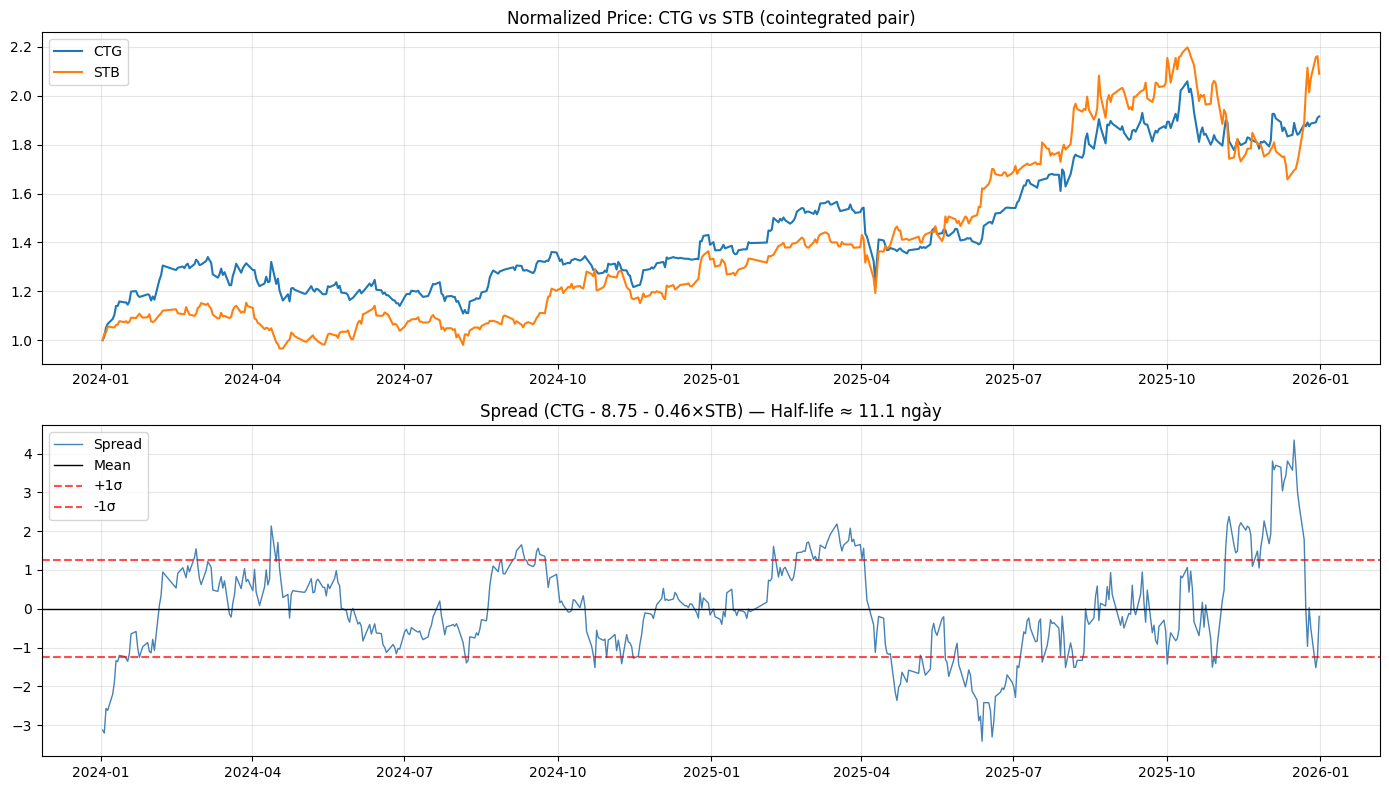

In [ ]:
# Cell 7: Visualize spread + mean reversion bands
import matplotlib.pyplot as plt

spread_mean = spread.mean()
spread_std = spread.std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Giá 2 mã (normalized để dễ so sánh trend)
ax1 = axes[0]
ax1.plot(price_df.index, price_df[sym1] / price_df[sym1].iloc[0], label=sym1, linewidth=1.5)
ax1.plot(price_df.index, price_df[sym2] / price_df[sym2].iloc[0], label=sym2, linewidth=1.5)
ax1.set_title(f"Normalized Price: {sym1} vs {sym2} (cointegrated pair)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Spread + mean-reversion bands
ax2 = axes[1]
ax2.plot(spread.index, spread.values, label="Spread", color="steelblue", linewidth=1)
ax2.axhline(spread_mean, color="black", linestyle="-", linewidth=1, label="Mean")
ax2.axhline(spread_mean + spread_std, color="red", linestyle="--", alpha=0.7, label="+1σ")
ax2.axhline(spread_mean - spread_std, color="red", linestyle="--", alpha=0.7, label="-1σ")
ax2.set_title(f"Spread ({sym1} - {alpha:.2f} - {beta:.2f}×{sym2}) — Half-life ≈ {half_life:.1f} ngày" if 0 < lam < 1 else "Spread")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cả 2 cổ phiếu nhìn từ biểu đồ giá đều có hướng di chuyển khá đồng nhất (giảm ở giữa 2025, và hồi phục vào cuối 2025)

Về sprear: Spread giai đoạn từ 2024 đến đầu 2025 khá ổn định, liên tục quay về 0 sau khi chạm mốc ±1σ

Tuy vậy, ở cuối năm 2025, spread lại lệch đí khá xa, có thể lên tới ±3σ

Đây là những cú sai lệch lớn, tuy vậy, vẫn sẽ quay về 0 (mean) với tốc độ khá nhanh

Tuy nhiên, điểm đáng lưu ý, nếu vào lệnh quá sớm thì ở giai đoạn này, mức max drawdown phải chịu cũng sẽ khá lớn

# Cell 8: Multiple testing

In [ ]:
from statsmodels.stats.multitest import multipletests

# Lý do cần: Cell 3 đã test cointegration cho TẤT CẢ C(11,2) = 55 cặp cùng lúc.
# Cặp có p-value thấp nhất (best_pair ở Cell 4) có thể chỉ "thấp nhất trong 55 phép test"
# do may mắn (data snooping), chứ chưa chắc thực sự cointegrated ở mức ý nghĩa 5%.
# Cần điều chỉnh ngưỡng theo số lượng test đã thực hiện.

alpha = 0.05
n_tests = len(coint_df)

p_array = coint_df["p_value"].values

# Bonferroni — kiểm soát Family-Wise Error Rate, bảo thủ (ngưỡng = alpha / n_tests)
reject_bonf, p_adj_bonf, _, _ = multipletests(p_array, alpha=alpha, method="bonferroni")

# Benjamini-Hochberg (FDR) — ít bảo thủ hơn, kiểm soát tỷ lệ false discovery kỳ vọng
reject_bh, p_adj_bh, _, _ = multipletests(p_array, alpha=alpha, method="fdr_bh")

coint_df["p_adj_bonferroni"] = p_adj_bonf
coint_df["sig_bonferroni"] = reject_bonf
coint_df["p_adj_bh"] = p_adj_bh
coint_df["sig_bh"] = reject_bh

correction_summary = coint_df[[
    "pair", "p_value", "p_adj_bonferroni", "sig_bonferroni", "p_adj_bh", "sig_bh"
]].sort_values("p_value").reset_index(drop=True)

print(f"Tổng số cặp test đồng thời: {n_tests}")
print(f"Ngưỡng Bonferroni tương đương: {alpha/n_tests:.6f}  (thay vì {alpha})")
print(f"\nTop 10 cặp theo p-value gốc, sau điều chỉnh:")
print(correction_summary.head(10).to_string(index=False))

n_raw = (coint_df["p_value"] < alpha).sum()
n_bonf = coint_df["sig_bonferroni"].sum()
n_bh = coint_df["sig_bh"].sum()

print(f"\n{'='*60}")
print(f"KẾT LUẬN — {n_tests} cặp được test đồng thời (α = {alpha})")
print(f"{'='*60}")
print(f"Significant KHÔNG điều chỉnh:  {n_raw}/{n_tests}  ← số này thường bị thổi phồng")
print(f"Significant sau Bonferroni:    {n_bonf}/{n_tests}  ← bảo thủ nhất")
print(f"Significant sau BH/FDR:        {n_bh}/{n_tests}  ← cân bằng, khuyến nghị dùng")

# --- Kiểm tra riêng cặp best_pair đã chọn ở Cell 4 để trade tiếp ---
best_row = coint_df[coint_df["pair"] == best_pair["pair"]].iloc[0]

print(f"\n{'='*60}")
print(f"KIỂM TRA CẶP ĐÃ CHỌN: {best_pair['pair']}")
print(f"{'='*60}")
print(f"p-value gốc:          {best_row['p_value']:.6f}")
print(f"p-value (Bonferroni): {best_row['p_adj_bonferroni']:.6f}  → {'✅ vẫn significant' if best_row['sig_bonferroni'] else '❌ KHÔNG còn significant sau điều chỉnh'}")
print(f"p-value (BH/FDR):     {best_row['p_adj_bh']:.6f}  → {'✅ vẫn significant' if best_row['sig_bh'] else '❌ KHÔNG còn significant sau điều chỉnh'}")

if not best_row["sig_bonferroni"]:
    print("\n⚠️  Cặp đang dùng cho spread/half-life ở Cell 4-7 KHÔNG sống sót qua Bonferroni.")
    print("   Kết quả cointegration có thể là false positive do test quá nhiều cặp cùng lúc —")
    print("   cân nhắc thận trọng khi diễn giải half-life và dùng cho trading thực tế.")

Tổng số cặp test đồng thời: 55
Ngưỡng Bonferroni tương đương: 0.000909  (thay vì 0.05)

Top 10 cặp theo p-value gốc, sau điều chỉnh:
   pair  p_value  p_adj_bonferroni  sig_bonferroni  p_adj_bh  sig_bh
CTG-STB 0.004069          0.223775           False  0.223775   False
MBB-STB 0.017747          0.976058           False  0.488029   False
ACB-VPB 0.041557          1.000000           False  0.539284   False
VCB-VPB 0.048737          1.000000           False  0.539284   False
VIB-VPB 0.049026          1.000000           False  0.539284   False
CTG-MBB 0.067431          1.000000           False  0.618116   False
ACB-STB 0.099971          1.000000           False  0.653589   False
ACB-TCB 0.113906          1.000000           False  0.653589   False
ACB-LPB 0.133933          1.000000           False  0.653589   False
STB-TCB 0.139121          1.000000           False  0.653589   False

KẾT LUẬN — 55 cặp được test đồng thời (α = 0.05)
Significant KHÔNG điều chỉnh:  5/55  ← số này thường bị th